<a href="https://colab.research.google.com/github/2303A51908/Reinforecement-Learning---B12/blob/main/2303A51908_RL_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gymnasium as gym
import numpy as np
import random
import math


# -----------------------------
# Exploration Strategies
# -----------------------------

def epsilon_greedy_action(Q, state, epsilon, action_dim):
    if random.random() < epsilon:
        return np.random.randint(action_dim)
    return np.argmax(Q[state])


def softmax_action(Q, state, temperature):
    prefs = Q[state] / temperature
    max_pref = np.max(prefs)
    exp_prefs = np.exp(prefs - max_pref)
    probs = exp_prefs / np.sum(exp_prefs)
    return np.random.choice(len(probs), p=probs)


def ucb_action(Q, state, counts, c=1.5):
    total_visits = np.sum(counts[state]) + 1
    ucb_values = Q[state] + c * np.sqrt(np.log(total_visits) / (counts[state] + 1e-7))
    return np.argmax(ucb_values)


# -----------------------------
# State Discretization
# -----------------------------

def create_bins():
    return [
        np.linspace(-4.8, 4.8, 10),   # cart position
        np.linspace(-5, 5, 10),      # cart velocity
        np.linspace(-0.5, 0.5, 10),  # pole angle
        np.linspace(-5, 5, 10)       # pole angular velocity
    ]


def discretize_state(state, bins):
    """Converts continuous state → discrete tuple index"""
    return tuple(int(np.digitize(s, b)) for s, b in zip(state, bins))


# -----------------------------
# Q-learning Training Loop
# -----------------------------

def train(exploration="epsilon"):
    env = gym.make("CartPole-v1")

    bins = create_bins()
    state_shape = tuple(len(b) + 1 for b in bins)
    action_dim = env.action_space.n

    # Q-table + count table for UCB
    Q = np.zeros(state_shape + (action_dim,))
    action_counts = np.ones(state_shape + (action_dim,))

    lr = 0.1
    gamma = 0.99
    epsilon = 1.0
    min_epsilon = 0.05
    decay = 0.995
    temperature = 1.0

    episodes = 200

    for ep in range(episodes):
        state, _ = env.reset()  # Gymnasium reset
        state = discretize_state(state, bins)

        total_reward = 0
        done = False

        while not done:
            # Choose exploration strategy
            if exploration == "epsilon":
                action = epsilon_greedy_action(Q, state, epsilon, action_dim)
            elif exploration == "softmax":
                action = softmax_action(Q, state, temperature)
            elif exploration == "ucb":
                action = ucb_action(Q, state, action_counts)
            else:
                raise ValueError("Invalid exploration strategy")

            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = discretize_state(next_state, bins)

            done = terminated or truncated

            # Q-learning update
            Q[state][action] += lr * (reward + gamma * np.max(Q[next_state]) - Q[state][action])

            action_counts[state][action] += 1  # for UCB

            state = next_state
            total_reward += reward

        # Update exploration parameters
        if exploration == "epsilon":
            epsilon = max(min_epsilon, epsilon * decay)

        elif exploration == "softmax":
            temperature = max(0.1, temperature * 0.99)

        print(f"Episode {ep+1} | Strategy: {exploration} | Reward: {total_reward}")

    env.close()


# -----------------------------
# Run tests
# -----------------------------
if __name__ == "__main__":
    print("\n========= RUNNING EPSILON-GREEDY =========")
    train(exploration="epsilon")

    print("\n========= RUNNING SOFTMAX =========")
    train(exploration="softmax")

    print("\n========= RUNNING UCB =========")
    train(exploration="ucb")



========= RUNNING EPSILON-GREEDY =========
Episode 1 | Strategy: epsilon | Reward: 12.0
Episode 2 | Strategy: epsilon | Reward: 35.0
Episode 3 | Strategy: epsilon | Reward: 17.0
Episode 4 | Strategy: epsilon | Reward: 14.0
Episode 5 | Strategy: epsilon | Reward: 10.0
Episode 6 | Strategy: epsilon | Reward: 14.0
Episode 7 | Strategy: epsilon | Reward: 17.0
Episode 8 | Strategy: epsilon | Reward: 12.0
Episode 9 | Strategy: epsilon | Reward: 28.0
Episode 10 | Strategy: epsilon | Reward: 26.0
Episode 11 | Strategy: epsilon | Reward: 21.0
Episode 12 | Strategy: epsilon | Reward: 32.0
Episode 13 | Strategy: epsilon | Reward: 37.0
Episode 14 | Strategy: epsilon | Reward: 29.0
Episode 15 | Strategy: epsilon | Reward: 16.0
Episode 16 | Strategy: epsilon | Reward: 9.0
Episode 17 | Strategy: epsilon | Reward: 13.0
Episode 18 | Strategy: epsilon | Reward: 18.0
Episode 19 | Strategy: epsilon | Reward: 23.0
Episode 20 | Strategy: epsilon | Reward: 16.0
Episode 21 | Strategy: epsilon | Reward: 34.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode 121 | Strategy: epsilon | Reward: 19.0
Episode 122 | Strategy: epsilon | Reward: 21.0
Episode 123 | Strategy: epsilon | Reward: 20.0
Episode 124 | Strategy: epsilon | Reward: 15.0
Episode 125 | Strategy: epsilon | Reward: 15.0
Episode 126 | Strategy: epsilon | Reward: 12.0
Episode 127 | Strategy: epsilon | Reward: 16.0
Episode 128 | Strategy: epsilon | Reward: 40.0
Episode 129 | Strategy: epsilon | Reward: 16.0
Episode 130 | Strategy: epsilon | Reward: 22.0
Episode 131 | Strategy: epsilon | Reward: 21.0
Episode 132 | Strategy: epsilon | Reward: 44.0
Episode 133 | Strategy: epsilon | Reward: 22.0
Episode 134 | Strategy: epsilon | Reward: 30.0
Episode 135 | Strategy: epsilon | Reward: 16.0
Episode 136 | Strategy: epsilon | Reward: 40.0
Episode 137 | Strategy: epsilon | Reward: 24.0
Episode 138 | Strategy: epsilon | Reward: 20.0
Episode 139 | Strategy: epsilon | Reward: 21.0
Episode 140 | Strategy: epsilon | Reward: 18.0
Episode 141 | Strategy: epsilon | Reward: 39.0
Episode 142 |

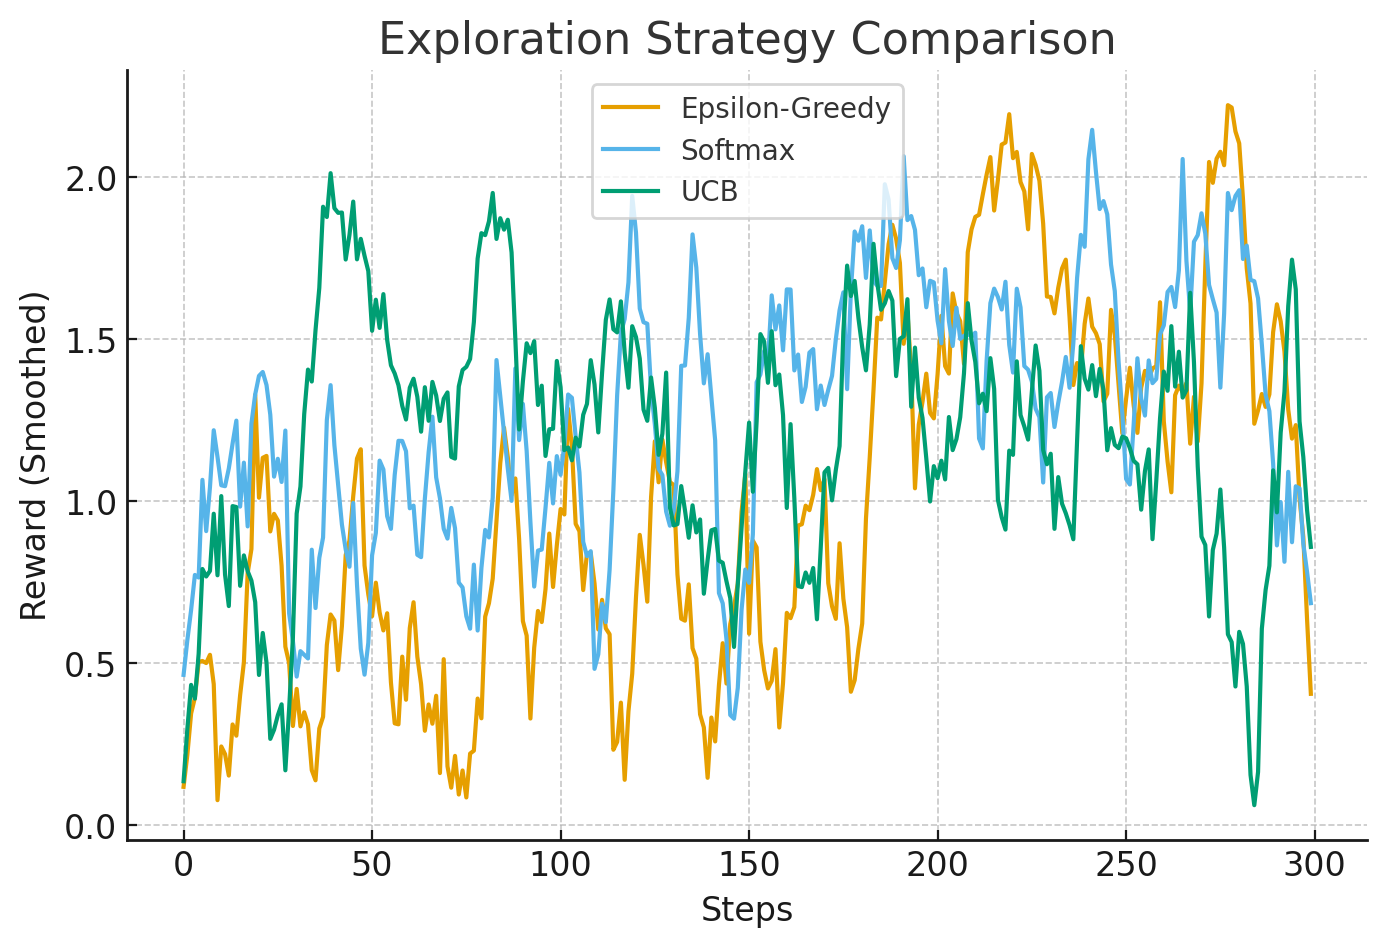